In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("D:/Machine Learning datasets/Regression Models/Walmart.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(6435, 8)
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 no

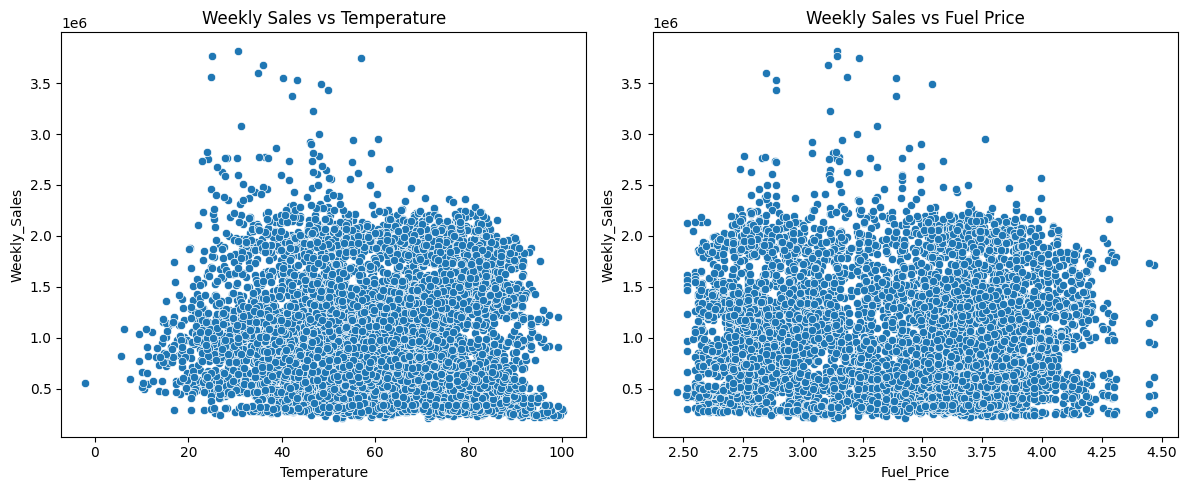

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=df["Temperature"], y=df["Weekly_Sales"])
plt.title("Weekly Sales vs Temperature")

plt.subplot(1,2,2)
sns.scatterplot(x=df["Fuel_Price"], y=df["Weekly_Sales"])
plt.title("Weekly Sales vs Fuel Price")

plt.tight_layout()
plt.show()

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [10]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe())

              Store          Date  Holiday_Flag   Temperature    Fuel_Price  \
count  5.148000e+03  5.148000e+03        5148.0  5.148000e+03  5.148000e+03   
mean  -9.109522e-17  3.726623e-17           0.0 -5.824573e-16  5.589934e-17   
std    1.000097e+00  1.000097e+00           0.0  1.000097e+00  1.000097e+00   
min   -1.703598e+00 -1.727275e+00           0.0 -2.934777e+00 -1.951693e+00   
25%   -8.567045e-01 -8.798217e-01           0.0 -7.140803e-01 -9.315360e-01   
50%   -9.810735e-03  1.605730e-02           0.0  1.133334e-01  2.090252e-01   
75%    8.370830e-01  8.635104e-01           0.0  7.717988e-01  8.198055e-01   
max    1.683977e+00  1.710964e+00           0.0  2.149919e+00  2.417905e+00   

                CPI  Unemployment  
count  5.148000e+03  5.148000e+03  
mean   5.044743e-16  7.052979e-16  
std    1.000097e+00  1.000097e+00  
min   -1.158416e+00 -2.352205e+00  
25%   -1.011950e+00 -6.438869e-01  
50%    2.862967e-01  2.859213e-03  
75%    1.040107e+00  4.949915e-01  


In [13]:
models_processed = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

processed_results = []

for name, model in models_processed.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    processed_results.append([
        name,
        mean_absolute_error(y_test, preds),
        mean_squared_error(y_test, preds),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    ])

In [14]:
processed_df = pd.DataFrame(
    processed_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)
print(processed_df)

               Model            MAE           MSE           RMSE        R2
0  Linear Regression  431816.831279  2.662627e+11  516006.450995  0.147594
1      Decision Tree   94201.218699  3.054006e+10  174757.139890  0.902230
2      Random Forest   69595.374010  1.703681e+10  130525.119240  0.945459


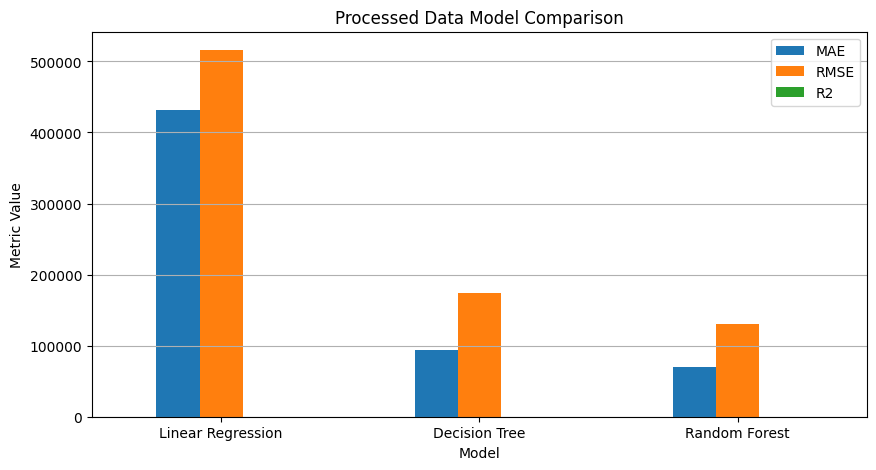

In [15]:
processed_df.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar", figsize=(10,5)
)
plt.title("Processed Data Model Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [16]:
for name, model in models_processed.items():
    train_r2 = model.score(X_train_scaled, y_train)
    test_r2 = model.score(X_test_scaled, y_test)
    print(f"{name} → Train R2: {train_r2:.3f}, Test R2: {test_r2:.3f}")

Linear Regression → Train R2: 0.138, Test R2: 0.148
Decision Tree → Train R2: 1.000, Test R2: 0.902
Random Forest → Train R2: 0.992, Test R2: 0.945


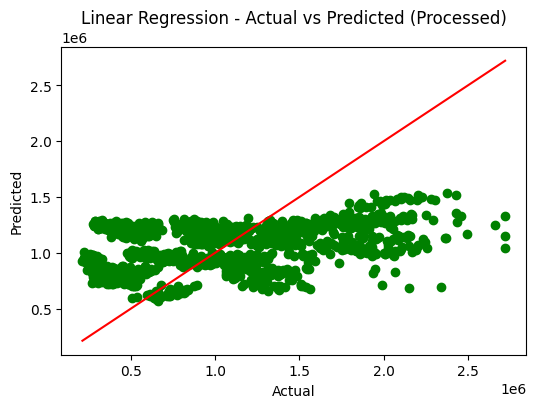

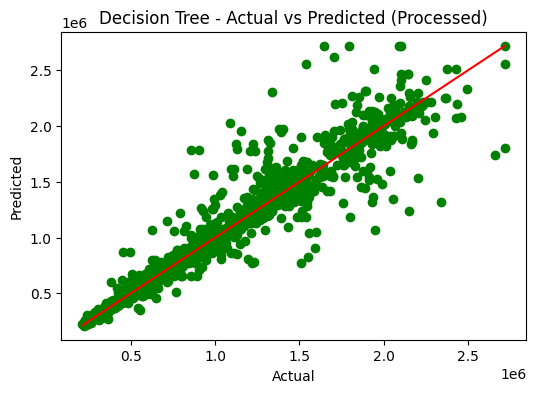

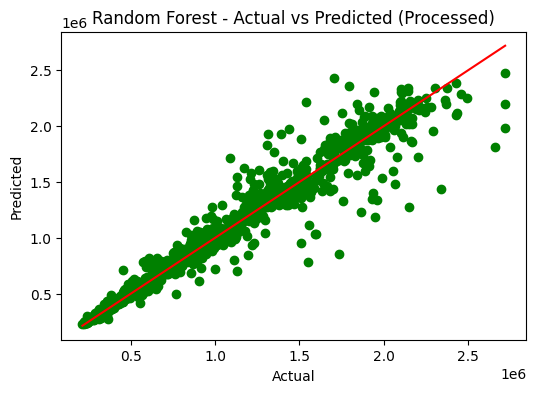

In [17]:
for name, model in models_processed.items():
    preds = model.predict(X_test_scaled)
    
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, preds, color="green")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red")
    plt.title(f"{name} - Actual vs Predicted (Processed)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [18]:
X_raw = X.copy()
y_raw = y.copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

In [19]:
models_raw = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

raw_results = []

for name, model in models_raw.items():
    model.fit(Xr_train, yr_train)
    preds = model.predict(Xr_test)
    
    raw_results.append([
        name,
        mean_absolute_error(yr_test, preds),
        mean_squared_error(yr_test, preds),
        np.sqrt(mean_squared_error(yr_test, preds)),
        r2_score(yr_test, preds)
    ])

               Model            MAE           MSE           RMSE        R2
0  Linear Regression  431816.831279  2.662627e+11  516006.450995  0.147594
1      Decision Tree   94324.333982  3.061304e+10  174965.826744  0.901996
2      Random Forest   69652.382932  1.706267e+10  130624.137404  0.945376


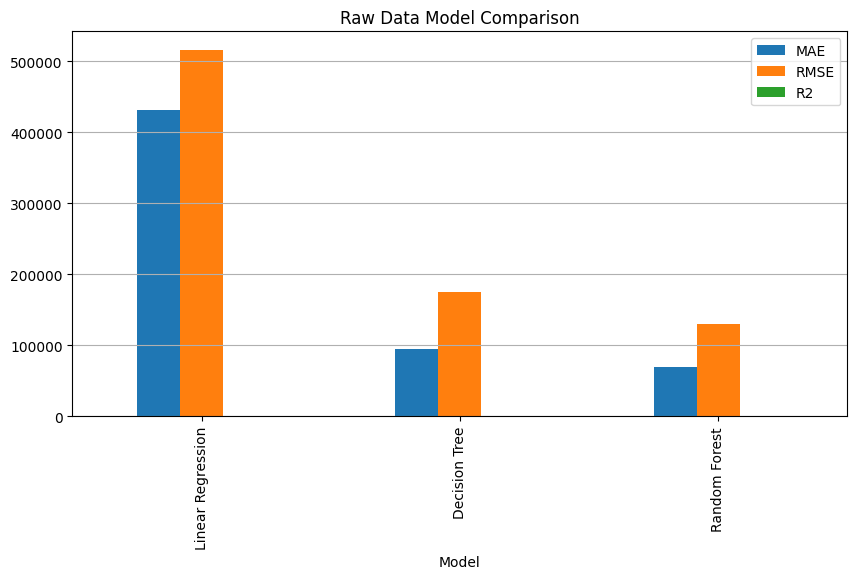

In [20]:
raw_df = pd.DataFrame(
    raw_results, columns=["Model","MAE","MSE","RMSE","R2"]
)
print(raw_df)

raw_df.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar", figsize=(10,5), title="Raw Data Model Comparison"
)
plt.grid(axis="y")
plt.show()

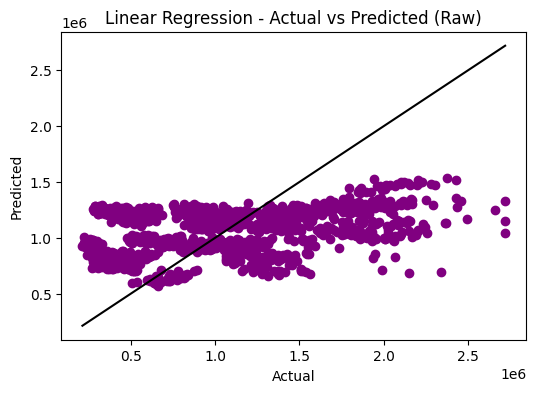

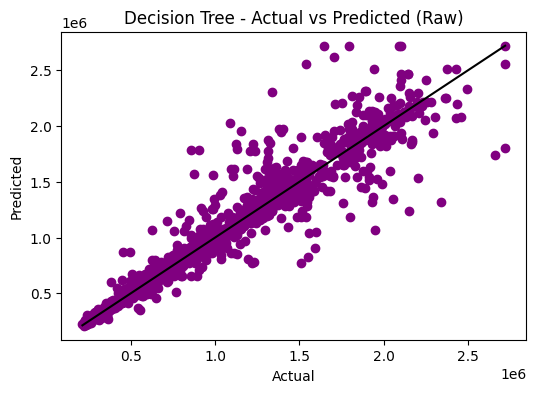

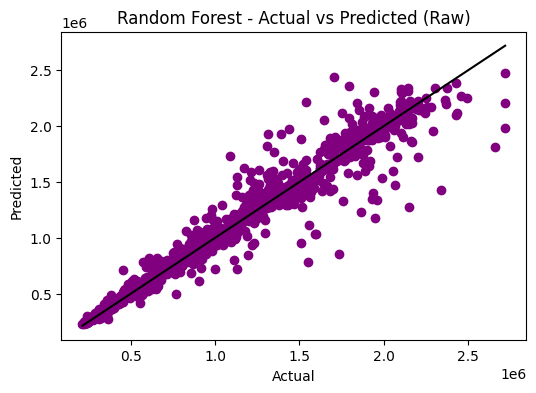

In [21]:
for name, model in models_raw.items():
    preds = model.predict(Xr_test)
    
    plt.figure(figsize=(6,4))
    plt.scatter(yr_test, preds, color="purple")
    plt.plot([yr_test.min(), yr_test.max()],
             [yr_test.min(), yr_test.max()],
             color="black")
    plt.title(f"{name} - Actual vs Predicted (Raw)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [22]:
joblib.dump(scaler, "walmart_scaler.pkl")

for name, model in models_processed.items():
    joblib.dump(model, f"{name.replace(' ','_')}_processed.pkl")

df.to_csv("processed_walmart_dataset.csv", index=False)